# Chapter 8 — Backpropagation Deep Dive

Chapter 5 introduced backprop as "the chain rule, applied layer by layer." This
notebook goes further, in three parts:

1. **Autodiff from scratch** — build a tiny automatic-differentiation engine
   (the same idea PyTorch's `autograd` is built on) and prove it reproduces
   Chapter 5's hand-derived gradient exactly. This is the bridge between
   "I can derive gradients by hand" and "I understand what a framework is
   doing when I call `.backward()`."
2. **Backprop through 3 layers** — Chapter 5 only went through 2. Adding a
   third layer shows the pattern is *recursive*: the same three-line recipe
   repeats at every layer, no matter how deep the network gets.
3. **Gradient flow** — watching gradient magnitude at each layer during
   training, a first look at why very deep networks can be hard to train
   (vanishing/exploding gradients).

## Part 1 — A computational graph, and why backprop works at all

Every expression a network computes — `w*x + b`, then `sigmoid(...)`, then
`(a - y)**2` — is a chain of small operations. Draw it as a graph: each node
is one operation, edges point from inputs to outputs.

```
w ──┐
    ×── z ──sigmoid── a ──(a-y)²── L
x ──┘         b ──┘
```

**Forward pass:** walk the graph left to right, computing each node's value.
**Backward pass:** walk it right to left. At each node, multiply the gradient
*flowing in from the right* (`dL/d(this node's output)`) by that node's own
**local derivative** (how its output changes with respect to its input) to get
the gradient to pass further left. That's the entire algorithm — Chapter 5's
`dL/da · da/dz · dz/dw` was one path through exactly this graph.

## Part 2 — Building a tiny autodiff engine

Instead of deriving `dL/dw` by hand every time, we can make *every arithmetic
operation remember how to backpropagate through itself*. Wrap numbers in a
`Value` class; every operation (`+`, `*`, `sigmoid`, ...) records how to route
the gradient backward through it. Calling `.backward()` on the final result
then walks the whole graph automatically — no manual chain-rule bookkeeping
required. This is a miniature version of what `requires_grad=True` and
`.backward()` do in PyTorch.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


class Value:
    """A scalar that remembers the operations used to produce it, so it can
    backpropagate a gradient through them automatically."""

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None   # how to route grad to _children; set by each op
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad          # local derivative of (a+b) w.r.t. a is 1
            other.grad += out.grad         # ... and w.r.t. b is also 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad   # d(a*b)/da = b
            other.grad += self.data * out.grad   # d(a*b)/db = a
        out._backward = _backward
        return out

    def __pow__(self, p):
        out = Value(self.data ** p, (self,), f'**{p}')
        def _backward():
            self.grad += p * (self.data ** (p - 1)) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')
        def _backward():
            self.grad += s * (1 - s) * out.grad   # sigmoid'(z) = s*(1-s), same as Ch.2/5
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-(other if isinstance(other, Value) else Value(other)))
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __repr__(self): return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def backward(self):
        """Topologically sort the graph, then apply the chain rule back to front."""
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0   # dL/dL = 1, the seed every backward pass starts from
        for v in reversed(topo):
            v._backward()

### Sanity check: does it reproduce Chapter 5's hand-derived gradient?

Chapter 5, Part 1 computed `dL/dw = -0.2376` by hand for
`x=2.0, w=0.5, b=-0.1, y=1.0`, using `z = wx+b`, `a = sigmoid(z)`, `L = (a-y)²`.
Build the identical expression with `Value` objects and let `.backward()` do
the chain rule for us.

In [2]:
x_val, y_val = Value(2.0), 1.0
w_val, b_val = Value(0.5), Value(-0.1)

z_val = w_val * x_val + b_val
a_val = z_val.sigmoid()
L_val = (a_val - y_val) ** 2

L_val.backward()

print(f"forward:   z={z_val.data:.4f}  a={a_val.data:.4f}  L={L_val.data:.4f}")
print(f"autodiff gradient  dL/dw = {w_val.grad:.6f}")
print(f"Chapter 5's hand-derived gradient was -0.237600")
print(f"match: {abs(w_val.grad - (-0.2376)) < 1e-6}")

forward:   z=0.9000  a=0.7109  L=0.0836
autodiff gradient  dL/dw = -0.237600
Chapter 5's hand-derived gradient was -0.237600
match: True


Exact match. This is the real point of the exercise: **manual backprop
(Chapter 5) and automatic differentiation (this `Value` class, and PyTorch's
real `autograd`) compute the identical number** — autodiff just automates the
bookkeeping so you never have to write `dL_da * da_dz * dz_dw` by hand again.
Everything from here on could, in principle, be built with `Value` objects
instead of the explicit numpy formulas — frameworks just do it with vectorized
tensors instead of one scalar at a time, for speed.

## Part 3 — Backprop through 3 layers: the pattern is recursive

Chapters 3–5 used 2 layers (`2 → 4 hidden → 1 output`). Add a **second hidden
layer** (`2 → 4 → 4 → 1`) and re-derive the backward pass. Watch the pattern:
the formula for layer *l* is always the same three lines, just applied one
layer further back each time.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def bce_loss(A, y):
    y = y.reshape(A.shape)
    eps = 1e-12
    p = np.clip(A, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def forward3(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1;   A1 = relu(Z1)
    Z2 = A1 @ W2 + b2;  A2 = relu(Z2)
    Z3 = A2 @ W3 + b3;  A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3


def backward3(X, y, cache, W2, W3):
    Z1, A1, Z2, A2, Z3, A3 = cache
    n = X.shape[0]
    y = y.reshape(A3.shape)

    # Layer 3 (output): identical to Ch.5's dZ2 formula, just renamed.
    dZ3 = (A3 - y) / n
    dW3 = A2.T @ dZ3
    db3 = dZ3.sum(axis=0)

    # Layer 2 (hidden): error flows back through W3, gated by where ReLU was active.
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_deriv(Z2)
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)

    # Layer 1 (hidden): SAME recipe again, one layer further back.
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)

    return dW1, db1, dW2, db2, dW3, db3

print("Notice: the layer-2 block and layer-1 block are structurally identical —")
print("dA_prev = dZ_next @ W_next.T ; dZ_prev = dA_prev * relu_deriv(Z_prev) ; dW = A_before.T @ dZ_prev")
print("That's the whole 'recursion' — depth just means applying this block more times.")

Notice: the layer-2 block and layer-1 block are structurally identical —
dA_prev = dZ_next @ W_next.T ; dZ_prev = dA_prev * relu_deriv(Z_prev) ; dW = A_before.T @ dZ_prev
That's the whole 'recursion' — depth just means applying this block more times.


### Gradient-checking the 3-layer network

Same trust-but-verify move as Chapter 5, now on the deeper network — nudge one
weight in the *first* layer (`W1`, the one furthest from the loss, whose
gradient depends on backprop having correctly threaded through *both* layers
above it) and compare against the numerical estimate.

In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

rng = np.random.default_rng(2)
W1 = rng.normal(scale=1.0, size=(2, 4)); b1 = np.zeros(4)
W2 = rng.normal(scale=1.0, size=(4, 4)); b2 = np.zeros(4)
W3 = rng.normal(scale=1.0, size=(4, 1)); b3 = np.zeros(1)

cache = forward3(X_xor, W1, b1, W2, b2, W3, b3)
dW1, db1, dW2, db2, dW3, db3 = backward3(X_xor, y_xor, cache, W2, W3)

def numerical_grad_W1(eps=1e-5):
    grad = np.zeros_like(W1)
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            W1p, W1m = W1.copy(), W1.copy()
            W1p[i, j] += eps; W1m[i, j] -= eps
            loss_p = bce_loss(forward3(X_xor, W1p, b1, W2, b2, W3, b3)[-1], y_xor)
            loss_m = bce_loss(forward3(X_xor, W1m, b1, W2, b2, W3, b3)[-1], y_xor)
            grad[i, j] = (loss_p - loss_m) / (2 * eps)
    return grad

numerical_dW1 = numerical_grad_W1()
print("max |analytic - numerical| for W1 (furthest layer from the loss):",
      np.max(np.abs(dW1 - numerical_dW1)))

max |analytic - numerical| for W1 (furthest layer from the loss): 4.2634895613957724e-11


The gradient for `W1` — three operations removed from the loss — still matches
the numerical estimate to the same precision as Chapter 5's single-hidden-layer
check. Backprop doesn't get less accurate with depth; it just does more
bookkeeping, which is exactly what the recursion (and the `Value` autodiff
engine in Part 2) handles for us.

## Part 4 — Gradient flow: a first look at vanishing gradients

Train the 3-layer network on XOR and track the *average gradient magnitude* in
each layer's weights, epoch by epoch. If gradients shrink sharply the further
back (further from the loss) a layer is, that layer's weights barely move —
the classic **vanishing gradient** problem that motivated moving from sigmoid
to ReLU in hidden layers (Chapter 2).

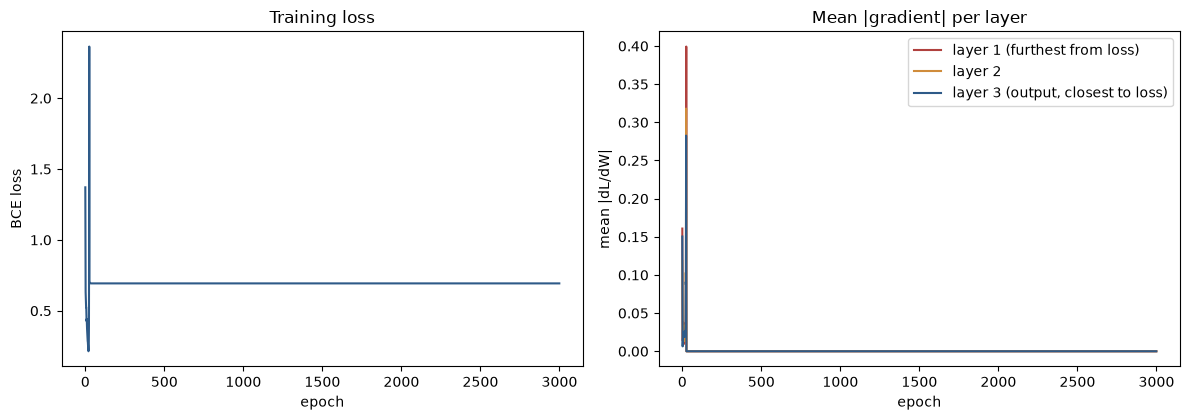

With only 3 ReLU layers on a 4-row dataset this network is far too shallow
to *suffer* from vanishing gradients — but the layer-1 vs layer-3 gap you
see here is the same effect that becomes crippling in 50+ layer networks.


In [5]:
def train3(X, y, lr, epochs, seed=2):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(scale=1.0, size=(2, 4)); b1 = np.zeros(4)
    W2 = rng.normal(scale=1.0, size=(4, 4)); b2 = np.zeros(4)
    W3 = rng.normal(scale=1.0, size=(4, 1)); b3 = np.zeros(1)

    losses, grad_mag_1, grad_mag_2, grad_mag_3 = [], [], [], []
    for _ in range(epochs):
        cache = forward3(X, W1, b1, W2, b2, W3, b3)
        losses.append(bce_loss(cache[-1], y))
        dW1, db1, dW2, db2, dW3, db3 = backward3(X, y, cache, W2, W3)

        grad_mag_1.append(np.mean(np.abs(dW1)))
        grad_mag_2.append(np.mean(np.abs(dW2)))
        grad_mag_3.append(np.mean(np.abs(dW3)))

        W1 -= lr*dW1; b1 -= lr*db1
        W2 -= lr*dW2; b2 -= lr*db2
        W3 -= lr*dW3; b3 -= lr*db3
    return losses, grad_mag_1, grad_mag_2, grad_mag_3

losses, g1, g2, g3 = train3(X_xor, y_xor, lr=1.0, epochs=3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(losses, color='#2E5A88')
axes[0].set_title('Training loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss')

axes[1].plot(g1, label='layer 1 (furthest from loss)', color='#B0413E')
axes[1].plot(g2, label='layer 2', color='#D08C3B')
axes[1].plot(g3, label='layer 3 (output, closest to loss)', color='#2E5A88')
axes[1].set_title('Mean |gradient| per layer')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mean |dL/dW|'); axes[1].legend()
plt.tight_layout()
plt.show()

print("With only 3 ReLU layers on a 4-row dataset this network is far too shallow")
print("to *suffer* from vanishing gradients — but the layer-1 vs layer-3 gap you")
print("see here is the same effect that becomes crippling in 50+ layer networks.")

## Recap

- Backpropagation is the chain rule, and it can be **automated**: the `Value`
  engine in Part 2 computes exactly what Chapter 5 derived by hand, just by
  recording operations and replaying them backward. That automation, scaled up
  to vectorized tensors, is what PyTorch/TensorFlow/JAX actually do.
- The backward-pass recipe for one layer (`dA_prev = dZ_next @ W_next.T`,
  gate by the activation's derivative, then `dW = A_before.T @ dZ`) is
  **the same recipe at every depth** — that's what makes backprop scale to
  networks with hundreds of layers.
- Gradient *magnitude* isn't automatically well-behaved across layers — a
  preview of why activation choice (Chapter 2), initialization
  (`symmetry_breaking_random_weights`), and architectural tricks (residual
  connections, normalization) matter enormously in very deep networks, even
  though they're invisible in a 3-layer XOR toy problem.

**Next:** [Chapter 9 — Batch vs. Online Learning](09_batch_vs_online_learning.ipynb)